## Preparation

### Libraries import & metadata storage definitions

In [3]:
import os
import numpy as np
import torch
from time import time

from torch.optim import AdamW, lr_scheduler
from torch.nn import CrossEntropyLoss
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import root_mean_squared_error

from matplotlib import pyplot as plt, colors, cm

In [4]:
checkpoint_dir = "checkpoints_imagenet"
graph_dir = "graphs_imagenet"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)

### Common key functions: plots & training

In [34]:
figsize_squared = (30, 7)
figsize_long = (3, 15)

In [5]:
def plot_metric(trains: list, 
                tests: list, 
                epochs: int, 
                model_name: str = "model",
                dataset_name: str = "dataset",
                metric_name: str = "metric",
                graph_dir: str = "graphs"):
    
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.plot(
        [i+1 for i in range(epochs)],
        trains, 
        "b.-", alpha=0.6, lw=0.3, ms=0.8,
        label="train " + metric_name
    )
    ax.plot(
        [i+1 for i in range(epochs)],
        tests, 
        "r.-", alpha=0.8, lw=0.3,
        label="test " + metric_name
    )
    ax.set(
        title=f"{model_name} {metric_name} on {dataset_name} for {epochs} epochs",
        xlabel="epochs", xlim=(-1, epochs+1), xticks=[i for i in range(0, epochs+1, 5)],
        ylabel=metric_name
    )
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()

    plt.savefig(os.path.join(graph_dir, f"regnet_{metric_name}_{epochs}epochs.png"))
    

def centralize_colormap(values, 
                        center: float = 0):
    values_min = values.min()
    values_max = values.max()
    border = max(abs(values_min), abs(values_max))
    
    return colors.TwoSlopeNorm(
        vmin=-border,
        vcenter=center, 
        vmax=border
    )


def plot_heatmap(values,
                 figsize = None,
                 cmap_name: str = "seismic",
                 title: str = "Weights heatmap"):    
    plt.figure(figsize=figsize or (25, 3))
    plt.imshow(
        values, 
        origin="lower",
        cmap=cmap_name, 
        norm=centralize_colormap(values),
        extent=(0, len(values[0]) + 1, 0, len(values) + 1)
    )  
    plt.title(title)  
    plt.colorbar()  
    plt.show() 


def plot_colored_barplot(values,
                         values_color,
                         cmap_name: str = "seismic",
                         edge_color: str = "black",
                         title: str = "Values barplot",
                         x_label: str = "",
                         y_label: str = ""):
    fig, ax = plt.subplots(figsize=(25, 5))
    
    values_cmap = plt.get_cmap(cmap_name)
    norm = centralize_colormap(values_color)
    ax.bar(
        [i for i in range(len(values))],
        values, 
        color=values_cmap(norm(values_color)),
        edgecolor=edge_color
    )
    
    scalar_map = cm.ScalarMappable(
        cmap=values_cmap, 
        norm=norm
    )
    scalar_map.set_array([])
    colorbar = plt.colorbar(scalar_map, ax=ax)
    colorbar.set_label("Percentage of variance explained")
    
    ax.set(
        title=title,
        xlabel=x_label,
        ylabel=y_label
    )
    plt.grid(True, alpha=0.3, zorder=0)
    plt.show() 

In [6]:
def validate_epoch(model: torch.nn.Module,
                   test_loader: DataLoader,
                   criterion,
                   device: torch.device = torch.device("cpu")):
    model.eval()

    test_loss = 0.0
    correct = 0
    total = 0
        
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
                
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
    test_acc = 100. * correct / total

    return test_loss, test_acc

## Dataset download & instantiation

### ImageNet-1K

В работе рассматривается задача классификации изображений, для которой используются модель [семейства RegNet](https://docs.pytorch.org/vision/main/models/regnet.html) версии RegNet_X_3_2_GF и датасет [ImageNet-1K (ILSVRC2017)](https://www.kaggle.com/competitions/imagenet-object-localization-challenge/overview). 

Датасет ImageNet содержит высокого (различного) разрешения, каждое из которых аннотировано с использованием синсетов WordNet и соотносится с 1 или более из 1000 классов; классы не сбалансированы. Подсеты имеют следующую мощность:
- train - 1,3 млн изображений,
- val - 50 тыс изображений,
- test - 100 тыс изображений.

Модель для ускорения обучения инициализируется весами, предобученными на датасете ImageNet со следующими метриками точности:
- acc1: 78.364,
- acc5: 93.992

без дообучения.

In [7]:
def make_val_loader_imagenet(val_dir: str, 
                             batch_size: int = 256, 
                             num_workers: int = 4,
                             picture_size: int = 224):
    transforms_val = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(picture_size),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        ),
    ])

    imagenet_val = datasets.ImageNet(
        root=val_dir, 
        split="val", 
        transform=transforms_val
    )

    return DataLoader(
        imagenet_val, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=num_workers, 
        pin_memory=True
    )

In [8]:
dataset_dir_imagenet = "/media/user/Hitachi/ILSVRC/Data/CLS-LOC"
dataset_name = "ImageNet"
picture_size = 224

n_classes = 1000
batch_size = 32
num_workers = 4

In [9]:
print(f"[ ] Creating dataset {dataset_name}...")
val_loader = make_val_loader_imagenet(dataset_dir_imagenet, batch_size, num_workers)
classes_names = val_loader.dataset.classes  # type: ignore
print(f"[V] Dataset {dataset_name} created")

[ ] Creating dataset ImageNet...
[V] Dataset ImageNet created


## Model preparation

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name() if device.type == "cuda" else device.type)

Device: NVIDIA GeForce GTX 1650


### RegNetX_3_2 download & instantiation

In [11]:
print("[ ] Instantiating model...")
regnetx_3_2 = models.regnet_x_3_2gf(weights=models.RegNet_X_3_2GF_Weights.DEFAULT, progress=True)
# regnetx_large = models.regnet_x_32gf(weights=models.RegNet_X_32GF_Weights.DEFAULT, progress=True)
regnetx_3_2.to(device)
regnetx_3_2_name = "RegNetX_3_2"
print(f"[V] {regnetx_3_2_name} with default weights instantiated")

[ ] Instantiating model...
[V] RegNetX_3_2 with default weights instantiated


In [12]:
max_lr = 0.01
weight_decay = 0.001

criterion = CrossEntropyLoss()
optimizer = AdamW(regnetx_3_2.parameters(), lr=max_lr, weight_decay=weight_decay)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

## Main pipeline

### Pipeline: validation, binarization, weights fuse

In [13]:
seed = 42
torch.manual_seed(seed)

@torch.inference_mode()
def validate_top1_top5_time(model, 
                            loader: DataLoader, 
                            device: torch.device):
    model.eval()
    top1_correct = 0
    top5_correct = 0
    total = 0
    
    start_time = time()

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        _, preds = logits.topk(5, dim=1, largest=True, sorted=True)

        correct = preds.eq(targets.view(-1, 1))
        top1_correct += correct[:, :1].sum().item()
        top5_correct += correct.sum().item()
        total += targets.size(0)
        
    val_time = time() - start_time

    return (top1_correct / total * 100,
            top5_correct / total * 100,
            val_time)
    
def pretty_print_top1_top5_time(model, 
                                loader: DataLoader, 
                                device: torch.device,
                                top1_orig = None,
                                top5_orig = None):    
    top1_new, top5_new, val_time = validate_top1_top5_time(model, loader, device)
    
    if top1_orig is not None:
        drop1 = top1_orig - top1_new
        drop1_report = f", drop: {drop1:.4f}"
    else:
        drop1, drop1_report = None, ""
    if top5_orig is not None:
        drop5 = top5_orig - top5_new
        drop5_report = f", drop: {drop5:.4f}"
    else:
        drop5, drop5_report = None, ""
        
    print(f"    Top-1 Accuracy:  {top1_new:.4f}{drop1_report}")
    print(f"    Top-5 Accuracy:  {top5_new:.4f}{drop5_report}")
    print(f"    Validation time: {val_time:.4f} s")
    return top1_new, top5_new, val_time, drop1, drop5


bin_values = []
scale_bin_coeff = 6   # scaling coefficient for binarization hook from 'ADD-ONs: Binarizarion function choice'
def binarize_hook(module, input):
    x, = input
    x_bin = 2 ** ((x+1).log2().mul(1/scale_bin_coeff).round().mul(scale_bin_coeff)) - 1
    
    global bin_values
    bin_values = x_bin.unique()
    
    return (x_bin,)


def fuse_avgpool_linear(model, 
                        input_size: int):
    device = next(model.parameters()).device
    
    weights = model.fc.weight.data  # [100, 1008] for RegNetX_3_2 on CIFAR-100
    bias = model.fc.bias.data if (model.fc.bias is not None) else torch.zeros(weights.shape[0])
    
    with torch.no_grad():
        random_input = torch.randn(1, 3, input_size, input_size).to(device)
        features = model.stem(random_input)
        features = model.trunk_output(features)
        features = model.avgpool(features)  # shape = [batch, channels, H, W] = [1, 1008, 1, 1] for RegNetX_3_2 on CIFAR-100
        H, W = features.shape[-2:]
    
    divisor = H * W
    weights_fused = weights.repeat(1, divisor) / divisor
    
    return weights_fused.to(device), bias.to(device)


def replace_linear(model,
                   new_weights,
                   new_bias = None):
    device = next(model.parameters()).device
    dtype = model.fc.weight.dtype 
    model.fc.weight.data = torch.from_numpy(new_weights).to(device, dtype=dtype)
    if new_bias is not None:
        model.fc.bias.data = torch.from_numpy(new_bias).to(device, dtype=dtype)

    
def mostleast_signific_classes(weights: torch.Tensor, 
                               feature_idx: int, 
                               dataloader: DataLoader, 
                               top_k: int = 5):
    class_weights = np.argsort(abs(weights[:, feature_idx]))
    class_names = dataloader.dataset.classes # type: ignore
    
    return {
        "top_classes_ids":        class_weights[-top_k:],
        "top_classes_names":      [class_names[class_id] for class_id in class_weights[-top_k:]],
        "top_classes_weights":    weights[class_weights[-top_k:]],
        "bottom_classes_ids":     class_weights[:top_k],
        "bottom_classes_names":   [class_names[class_id] for class_id in class_weights[:top_k]],
        "bottom_classes_weights": weights[class_weights[:top_k]]
    }

In [14]:
print("\nValidating model before binarizing:")
top1_orig, top5_orig, val_time, _, _ = pretty_print_top1_top5_time(
    regnetx_3_2, val_loader, device
)


Validating model before binarizing:
    Top-1 Accuracy:  80.9900
    Top-5 Accuracy:  95.4040
    Validation time: 1035.5911 s


In [15]:
print("\n2. Binarizing input of avgpool layer...\n")
regnetx_3_2.avgpool.register_forward_pre_hook(binarize_hook)

print("\n[ ] Validating model after binarizing:")
top1_bin, top5_bin, val_time, _, _ = pretty_print_top1_top5_time(
    regnetx_3_2, val_loader, device, 
    top1_orig=top1_orig, 
    top5_orig=top5_orig
)


2. Binarizing input of avgpool layer...


[ ] Validating model after binarizing:
    Top-1 Accuracy:  78.6300, drop: 2.3600
    Top-5 Accuracy:  94.6520, drop: 0.7520
    Validation time: 500.2775 s


In [16]:
print("Binary values of last layer input:")
bin_values

Binary values of last layer input:


tensor([ 0., 63.], device='cuda:0')

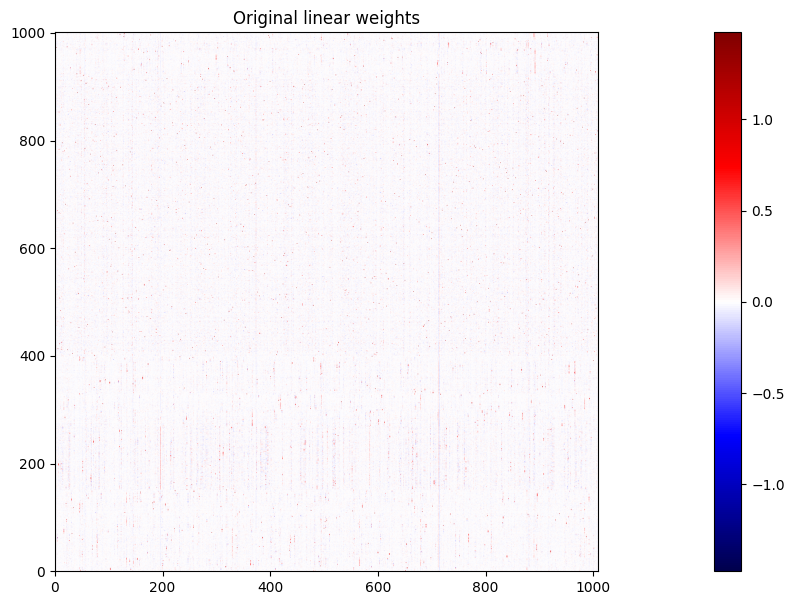

In [ ]:
plot_heatmap(regnetx_3_2.fc.weight.data.cpu(), figsize=figsize_squared, title="Original linear weights")

In [18]:
print("\n3. Avgpool and linear layers fusing...\n")
weights_fused, bias_fused = fuse_avgpool_linear(regnetx_3_2, picture_size)
print("    Fused weight matrix shape:", weights_fused.shape)  # [100, 1008*H*W]


3. Avgpool and linear layers fusing...

    Fused weight matrix shape: torch.Size([1000, 1008])


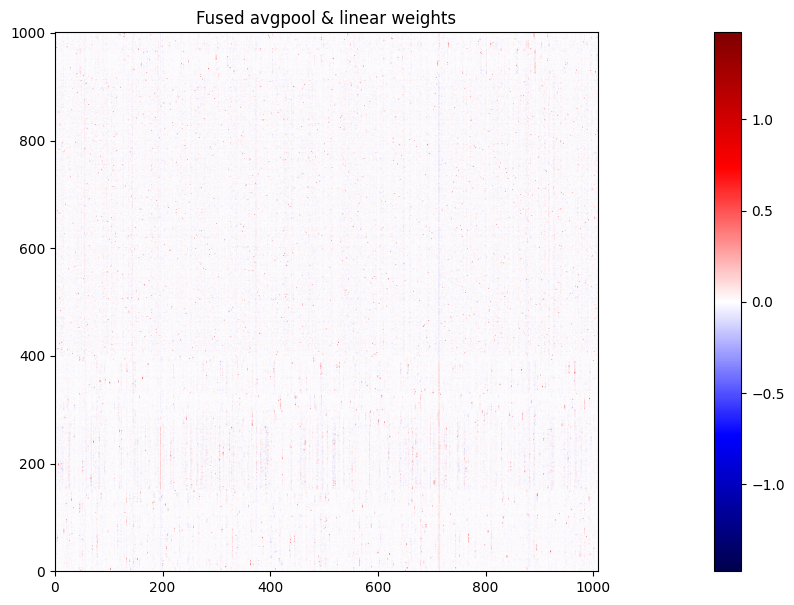

In [36]:
plot_heatmap(weights_fused.cpu(), figsize=figsize_squared, title="Fused avgpool & linear weights")

### Significant features extraction

In [20]:
torch.manual_seed(seed)

n_svd_components = 50

print("\n4. SVD...\n")
svd = TruncatedSVD(n_components=n_svd_components, random_state=seed)
weights_reduced = svd.fit_transform(weights_fused.cpu())
print("    Explained variance ratio:", svd.explained_variance_ratio_.sum())


4. SVD...

    Explained variance ratio: 0.1697378


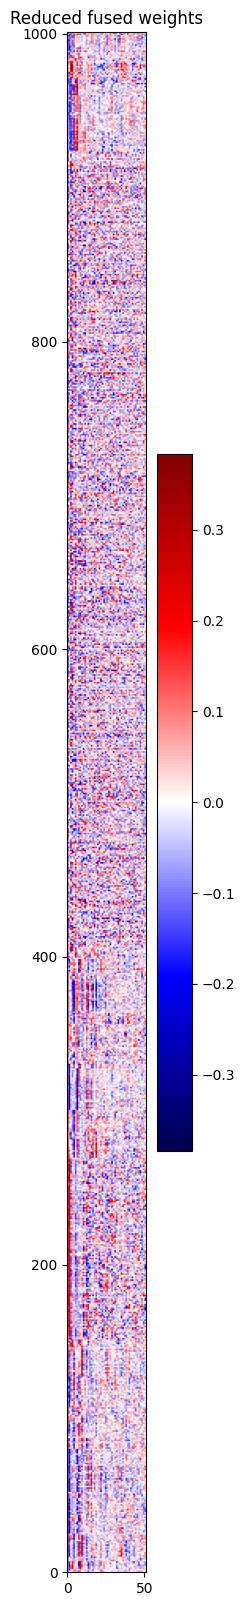

In [33]:
plot_heatmap(weights_reduced, figsize=(3, 20), title="Reduced fused weights")

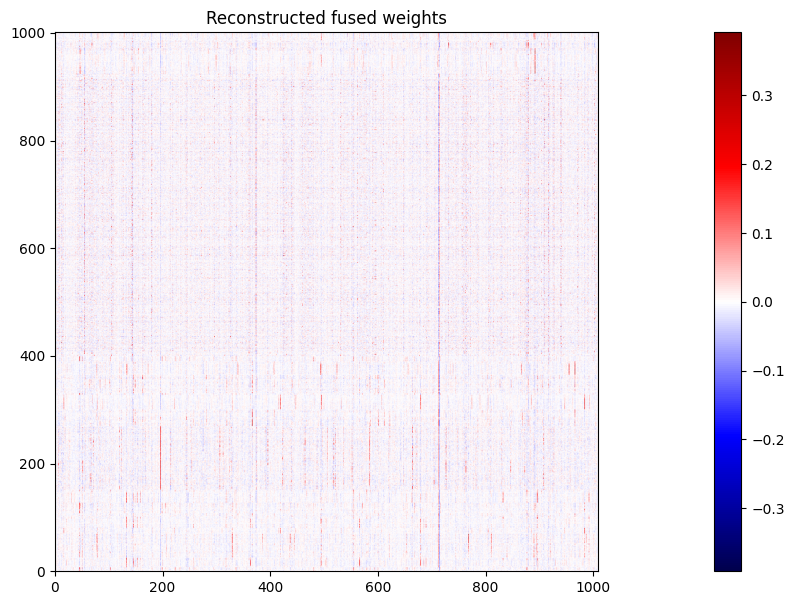

Reconstruction RMSE:      0.042326


In [ ]:
svd_right_sing_vecs = svd.components_  # [n_svd_components, 1008*H*W]
weights_reconstructed = svd.inverse_transform(weights_reduced)

plot_heatmap(weights_reconstructed, figsize=figsize_squared, title="Reconstructed fused weights")
print(f"Reconstruction RMSE:\
      {root_mean_squared_error(weights_fused.cpu().numpy(), weights_reconstructed):.6f}")

### SVD details analysis


5. Extracting significant features...



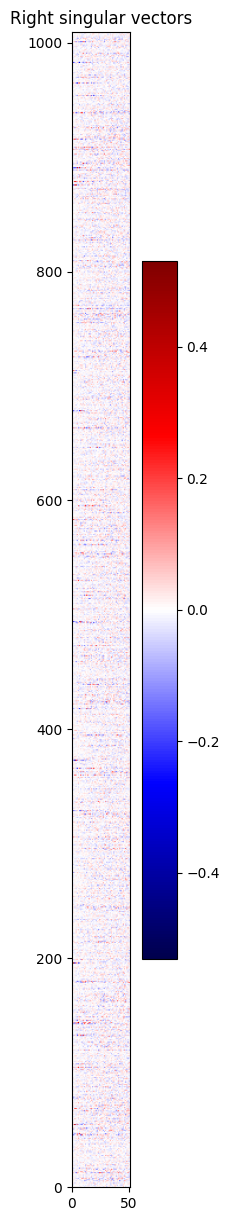

In [ ]:
print("\n5. Extracting significant features...\n")

plot_heatmap(
    np.transpose(svd_right_sing_vecs), 
    figsize=figsize_long,
    title="Right singular vectors"
)

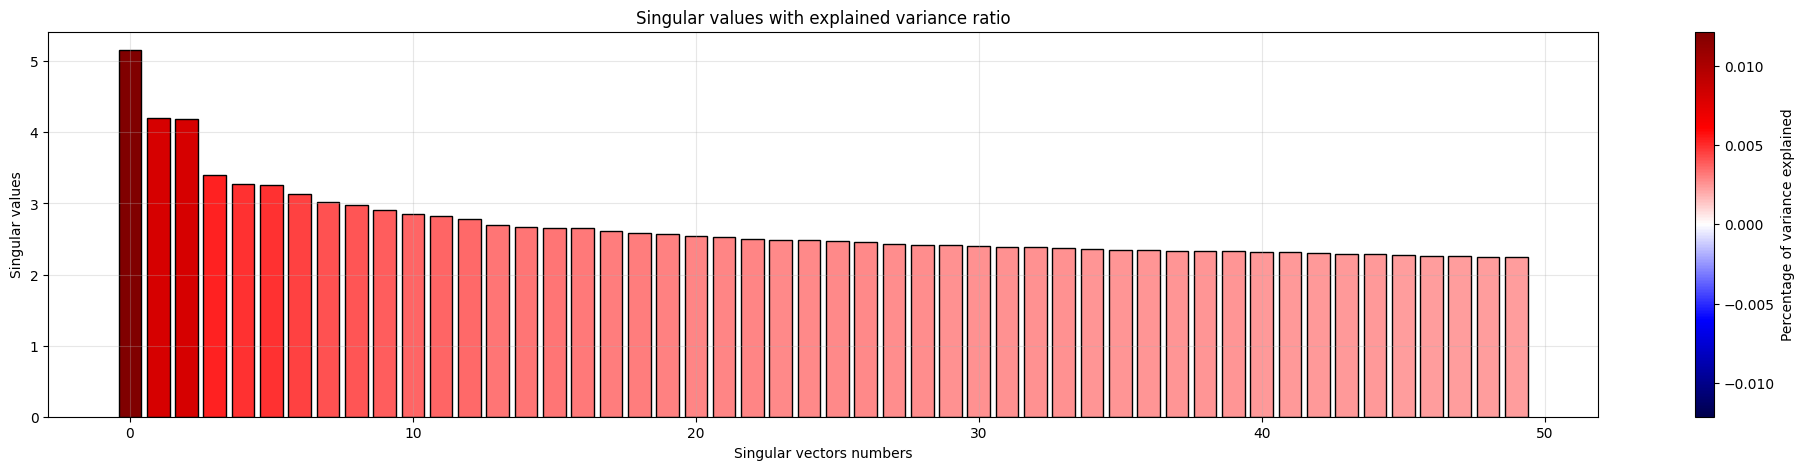

In [24]:
svd_sing_values = svd.singular_values_
svd_expl_var_ratio = svd.explained_variance_ratio_

plot_colored_barplot(
    values=svd_sing_values,
    values_color=svd_expl_var_ratio,
    title="Singular values with explained variance ratio",
    x_label="Singular vectors numbers",
    y_label="Singular values"
)

In [25]:
print("Top-5 singular values:                ", svd_sing_values[:5])
print("Top-5 (according) explained variences:", svd_expl_var_ratio[:5])

Top-5 singular values:                 [5.156464  4.200635  4.1810517 3.393372  3.279477 ]
Top-5 (according) explained variences: [0.01213398 0.00805249 0.00797757 0.00525488 0.00490805]


### Significant features count as: singular vectors, reduced features, reconstructed features

In [135]:
def calc_ljust_spaces(signific_thresholds: list):
    n = 3
    
    thresholds_str = []
    for thr in signific_thresholds:
        thr_str = f"{thr:.{n}f}"
        thresholds_str.append(
            thr_str.rstrip('0').rstrip('.') if ('.' in thr_str) else thr_str
        )
    return thresholds_str, max(len(thr_str) for thr_str in thresholds_str) 


def signific_features_count(weights,
                            signific_thresholds: list,
                            weights_name: str = "",
                            is_strict: bool = False):
    thresholds_str, max_threshold_len = calc_ljust_spaces(signific_thresholds)
    
    signific_features_ns =  [ np.sum(np.abs(weights) > threshold) 
                             for threshold in signific_thresholds ] \
                            if is_strict else \
                            [ np.sum(np.abs(weights) >= threshold) 
                             for threshold in signific_thresholds ]

    print(f"    Percent of significant {weights_name} features:")
    sign = ">" if is_strict else ">="
    for i in range(len(signific_thresholds)):
        print(
            f"        {sign} {thresholds_str[i].ljust(max_threshold_len)}: ", 
            f"{signific_features_ns[i] / weights.size:.3%}"        
        )
    print("    of all features after SVD")

In [ ]:
print("\n6.1 Counting significant singular features...\n")

signific_sing_thresholds = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.75]
signific_features_count(svd_right_sing_vecs, signific_sing_thresholds, "singular")


6.1 Counting significant singular features...

    Percent of significant singular features:
        >= 0.01:  67.429%
        >= 0.05:  9.183%
        >= 0.1 :  1.020%
        >= 0.15:  0.196%
        >= 0.2 :  0.071%
        >= 0.25:  0.028%
        >= 0.5 :  0.004%
        >= 0.75:  0.000%
    of all features after SVD


In [42]:
print("\n6.2 Counting significant reduced features...\n")

signific_red_thresholds = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
signific_features_count(weights_reduced, signific_red_thresholds, "reduced")


6.2 Counting significant reduced features...

    Percent of significant reduced features:
        >= 0.01:  89.420%
        >= 0.05:  51.738%
        >= 0.1 :  21.886%
        >= 0.15:  8.418%
        >= 0.2 :  3.176%
        >= 0.25:  1.086%
        >= 0.3 :  0.254%
        >= 0.35:  0.050%
        >= 0.4 :  0.000%
    of all features after SVD


In [136]:
print("\n6.3 Counting significant reconstructed features...\n")

signific_rec_thresholds = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
signific_features_count(
    weights_reconstructed, 
    signific_rec_thresholds, 
    "(binary in perspective) reconstructed"
)


6.3 Counting significant reconstructed features...

    Percent of significant (binary in perspective) reconstructed features:
        >= 0.01:  43.587%
        >= 0.05:  1.971%
        >= 0.1 :  0.413%
        >= 0.15:  0.147%
        >= 0.2 :  0.056%
        >= 0.25:  0.016%
        >= 0.3 :  0.004%
        >= 0.35:  0.001%
        >= 0.4 :  0.000%
    of all features after SVD


### Significant features binarization

In [129]:
print("\n7. Binarizing significant features...\n")
print("7.1 Binary weights analysis:\n")

signific_threshold = 0.1

filtered_weights = np.where(
    abs(weights_reconstructed) >= signific_threshold, 
    weights_reconstructed, 0
)
weights_binary = 2 ** (
    np.round(np.log2(abs(filtered_weights) + 1) * (2)) * 1/2
) - 1

filtered_weights_stats = {
    "max":  filtered_weights.max(),
    "min":  filtered_weights.min(),
    "mean": filtered_weights.mean(),
    "sdev": np.std(filtered_weights),
    "binary_values": np.unique(weights_binary)
}

print(f"    Significant (for threshold {signific_threshold}) reduced weights statistics:")
print("        max:      ", filtered_weights_stats["max"])
print("        min:      ", filtered_weights_stats["min"])
print("        mean:     ", filtered_weights_stats["mean"])
print("        deviation:", filtered_weights_stats["sdev"])
print("        binary values:", filtered_weights_stats["binary_values"])


7. Binarizing significant features...

7.1 Binary weights analysis:

    Significant (for threshold 0.1) reduced weights statistics:
        max:       0.39156055
        min:       -0.172703
        mean:      0.0005156745
        deviation: 0.009898738
        binary values: [0.         0.41421354]


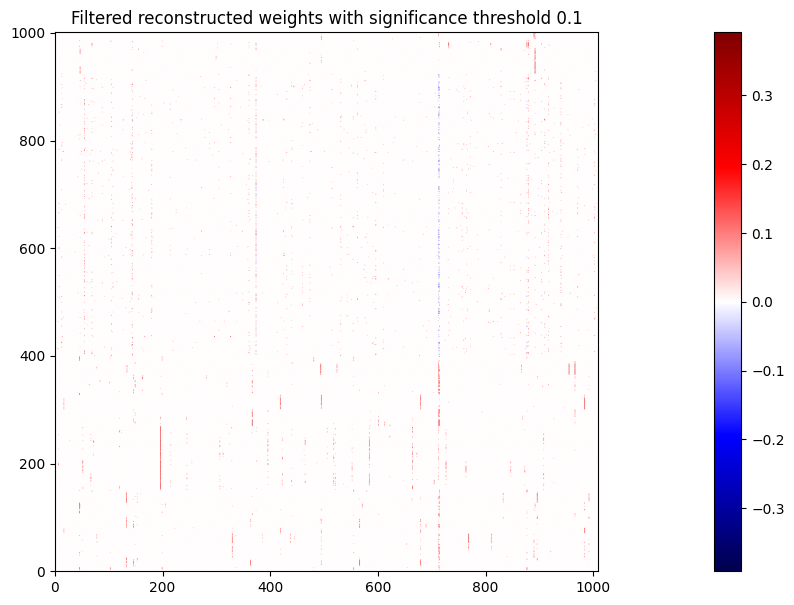

In [130]:
plot_heatmap(
    filtered_weights, 
    figsize=figsize_squared,
    title=f"Filtered reconstructed weights with significance threshold {signific_threshold}"
)

    Binary features values: [0.         0.41421354]
    Binary features shape:  (1000, 1008)


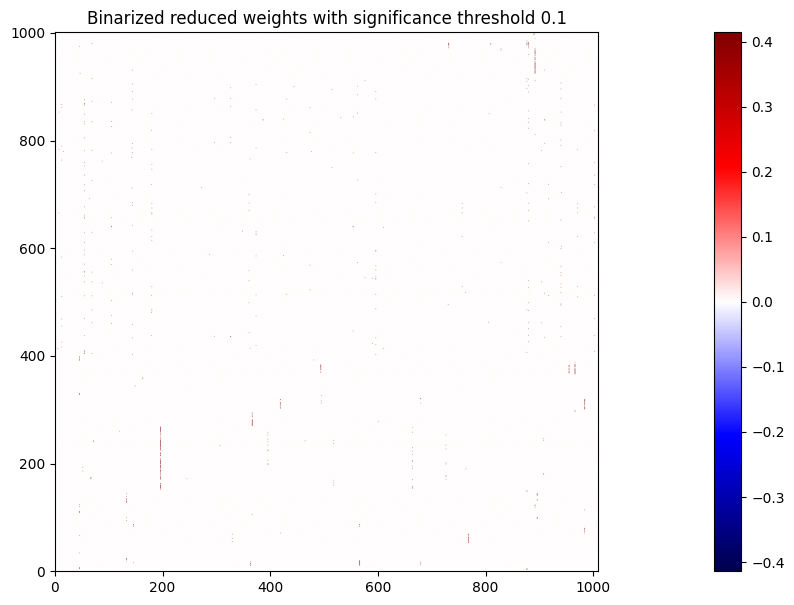

In [131]:
print("    Binary features values:", np.unique(weights_binary))
print("    Binary features shape: ", weights_binary.shape)

plot_heatmap(
    weights_binary, 
    figsize=figsize_squared,
    title=f"Binarized reduced weights with significance threshold {signific_threshold}"
)

In [137]:
print("\n6.5 Counting non-zero binary features...\n")

signific_bin_thresholds = [0]
signific_features_count(
    weights_binary, 
    signific_bin_thresholds, 
    "binary",
    is_strict=True
)


6.5 Counting non-zero binary features...

    Percent of significant binary features:
        > 0:  0.068%
    of all features after SVD


## Significant features semantic analysis

### Significant classes analysis

7.2 Significant classes per feature analysis:



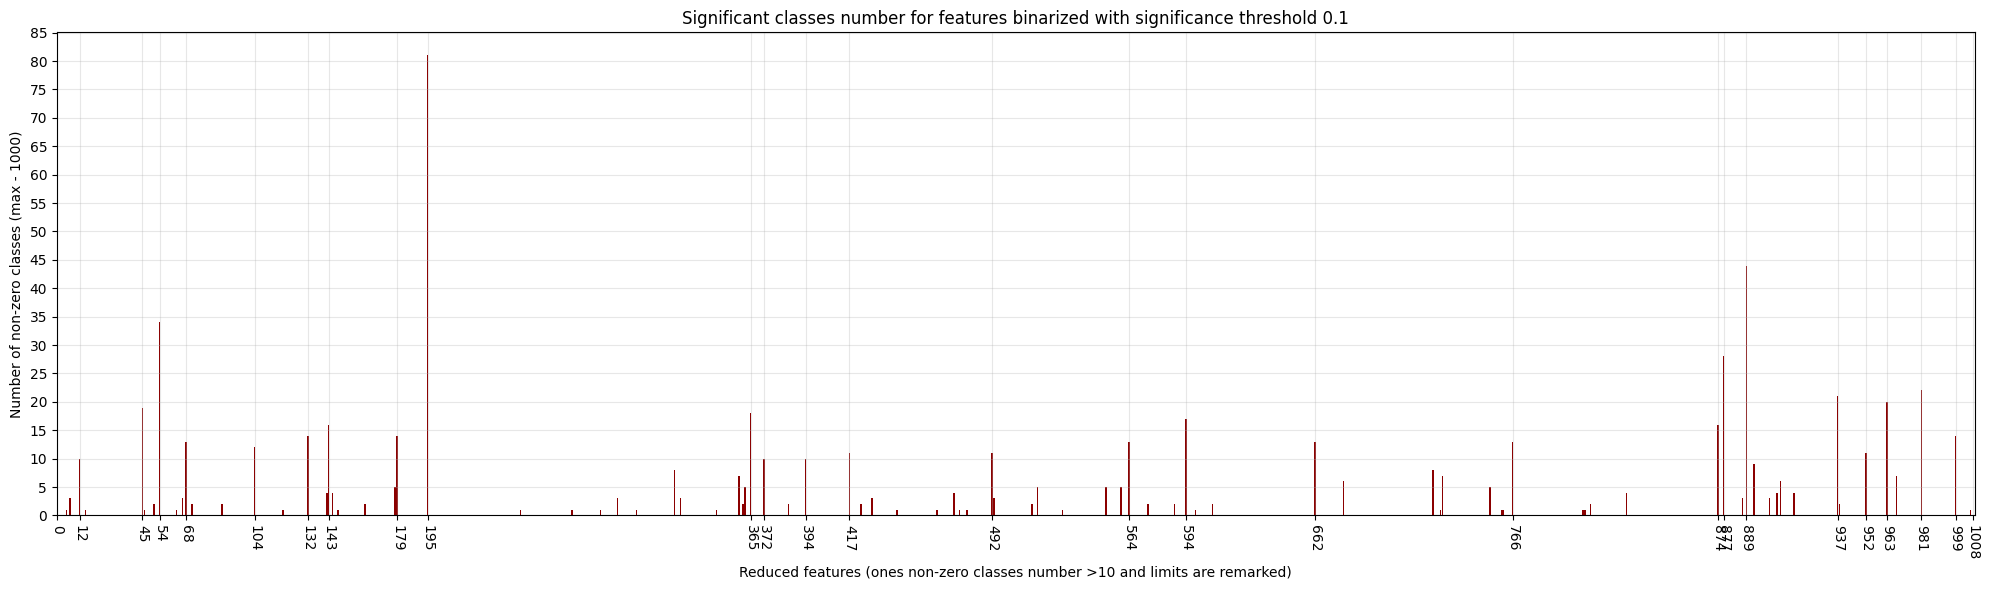

In [142]:
print("7.2 Significant classes per feature analysis:\n")

n_classes_chosen = [ np.where(weights_binary[:, feature_i])[0].size 
                     for feature_i in range(weights_binary.shape[1]) ]

n_classes_tick_limit = 10
n_largest_classes_ids = [ i for i in range(len(n_classes_chosen))
                          if (n_classes_chosen[i] >= n_classes_tick_limit) ]

fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(
    [i for i in range(len(n_classes_chosen))], 
    n_classes_chosen,
    color="darkred"
)

yticks_max_classes = [i for i in range(max(n_classes_chosen) + 1)] \
                    if max(n_classes_chosen) <= 30 else \
                    [i for i in range(0, max(n_classes_chosen) + 5, 5)]
ax.set(
    xticks=n_largest_classes_ids + [0, len(n_classes_chosen)],
    xlim=(0, len(n_classes_chosen) + 1),
    xlabel=f"Reduced features (ones non-zero classes number >{n_classes_tick_limit} and limits are remarked)",
    yticks=yticks_max_classes,
    ylabel=f"Number of non-zero classes (max - {n_classes})", 
    title=f"Significant classes number for features binarized with significance threshold {signific_threshold}"
)
ax.set_xticklabels(ax.get_xticks(), rotation=-90)
ax.grid(alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()

In [143]:
features_classes_choice = { 
    feature_i: np.where(weights_binary[:, feature_i])[0]
    for feature_i in range(weights_binary.shape[1])
    if np.where(weights_binary[:, feature_i])[0].size 
}
classes_features_choice = { 
    class_i: np.where(weights_binary[class_i])[0]
    for class_i in range(n_classes)
    if np.where(weights_binary[class_i])[0].size 
}

In [144]:
print("    The following features choose the following classes:\n")
for feature_i in features_classes_choice.keys():
    names_chosen = [ classes_names[name_i] for name_i in features_classes_choice[feature_i]]
    print(feature_i, " - ", len(names_chosen), "classes: ", names_chosen)

    The following features choose the following classes:

5  -  1 classes:  [('ashcan', 'trash can', 'garbage can', 'wastebin', 'ash bin', 'ash-bin', 'ashbin', 'dustbin', 'trash barrel', 'trash bin')]
7  -  3 classes:  [('monitor',), ('screen', 'CRT screen'), ('television', 'television system')]
12  -  10 classes:  [('bakery', 'bakeshop', 'bakehouse'), ('barbershop',), ('bookshop', 'bookstore', 'bookstall'), ('butcher shop', 'meat market'), ('confectionery', 'confectionary', 'candy store'), ('grocery store', 'grocery', 'food market', 'market'), ('restaurant', 'eating house', 'eating place', 'eatery'), ('shoe shop', 'shoe-shop', 'shoe store'), ('tobacco shop', 'tobacconist shop', 'tobacconist'), ('toyshop',)]
15  -  1 classes:  [('scale', 'weighing machine')]
45  -  19 classes:  [('hammerhead', 'hammerhead shark'), ('electric ray', 'crampfish', 'numbfish', 'torpedo'), ('stingray',), ('loggerhead', 'loggerhead turtle', 'Caretta caretta'), ('sea snake',), ('sea anemone', 'anemone'), ('bra

In [149]:
print("The following classes are chosen by the following features:\n")
for class_i in classes_features_choice.keys():
    print(
        "Class\n"
        "   ", class_i, classes_names[class_i],
        f"\n    is activated by {len(classes_features_choice[class_i])} features: {classes_features_choice[class_i]}"
    )

The following classes are chosen by the following features:

Class
    2 ('great white shark', 'white shark', 'man-eater', 'man-eating shark', 'Carcharodon carcharias') 
    is activated by 1 features: [874]
Class
    3 ('tiger shark', 'Galeocerdo cuvieri') 
    is activated by 1 features: [874]
Class
    4 ('hammerhead', 'hammerhead shark') 
    is activated by 2 features: [ 45 874]
Class
    5 ('electric ray', 'crampfish', 'numbfish', 'torpedo') 
    is activated by 1 features: [45]
Class
    6 ('stingray',) 
    is activated by 1 features: [45]
Class
    10 ('brambling', 'Fringilla montifringilla') 
    is activated by 2 features: [362 564]
Class
    11 ('goldfinch', 'Carduelis carduelis') 
    is activated by 3 features: [362 564 677]
Class
    12 ('house finch', 'linnet', 'Carpodacus mexicanus') 
    is activated by 1 features: [564]
Class
    13 ('junco', 'snowbird') 
    is activated by 2 features: [362 564]
Class
    14 ('indigo bunting', 'indigo finch', 'indigo bird', 'Passeri

In [146]:
max_choosing_features = 0
most_popular_classes = []

for class_i in classes_features_choice.keys():
    n_choosing_features = len(classes_features_choice[class_i])
    
    if n_choosing_features == max_choosing_features:
        most_popular_classes.append(class_i)
        
    elif n_choosing_features > max_choosing_features:
        max_choosing_features = n_choosing_features
        most_popular_classes = [class_i]
 
print(f"The following classes are chosen by maximum number of features - {max_choosing_features}:\n")
for class_i in most_popular_classes:
    print(classes_features_choice[class_i], "choose", class_i, classes_names[class_i])

The following classes are chosen by maximum number of features - 5:

[ 68 729 807 874 877] choose 978 ('seashore', 'coast', 'seacoast', 'sea-coast')


In [147]:
for n_choosing_features in range(2, max_choosing_features + 1):
    print(f"\nThe following classes are chosen by {n_choosing_features} features:\n")
    for class_i in classes_features_choice.keys():
        if len(classes_features_choice[class_i]) == n_choosing_features:
            print(classes_features_choice[class_i], "choose", class_i, classes_names[class_i])


The following classes are chosen by 2 features:

[ 45 874] choose 4 ('hammerhead', 'hammerhead shark')
[362 564] choose 10 ('brambling', 'Fringilla montifringilla')
[362 564] choose 13 ('junco', 'snowbird')
[145 564] choose 15 ('robin', 'American robin', 'Turdus migratorius')
[564 677] choose 16 ('bulbul',)
[362 564] choose 17 ('jay',)
[132 564] choose 18 ('magpie',)
[328 766] choose 54 ('hognose snake', 'puff adder', 'sand viper')
[328 766] choose 60 ('night snake', 'Hypsiglena torquata')
[328 766] choose 68 ('sidewinder', 'horned rattlesnake', 'Crotalus cerastes')
[417 981] choose 70 ('harvestman', 'daddy longlegs', 'Phalangium opilio')
[145 564] choose 82 ('ruffed grouse', 'partridge', 'Bonasa umbellus')
[145 564] choose 85 ('quail',)
[145 564] choose 86 ('partridge',)
[132 893] choose 99 ('goose',)
[132 893] choose 131 ('little blue heron', 'Egretta caerulea')
[132 893] choose 132 ('American egret', 'great white heron', 'Egretta albus')
[132 893] choose 143 ('oystercatcher', 'oyst

### Insignificant classes analysis

In [148]:
classes_unchosen =[ class_i for class_i in range(n_classes) 
                    if not np.where(weights_binary[class_i])[0].size]
print(f"There are {len(classes_unchosen)}/{n_classes} classes not chosen by any feature:") 
for class_i in classes_unchosen:
    print(class_i, classes_names[class_i])

There are 504/1000 classes not chosen by any feature:
0 ('tench', 'Tinca tinca')
1 ('goldfish', 'Carassius auratus')
7 ('cock',)
8 ('hen',)
9 ('ostrich', 'Struthio camelus')
20 ('water ouzel', 'dipper')
24 ('great grey owl', 'great gray owl', 'Strix nebulosa')
25 ('European fire salamander', 'Salamandra salamandra')
26 ('common newt', 'Triturus vulgaris')
27 ('eft',)
28 ('spotted salamander', 'Ambystoma maculatum')
29 ('axolotl', 'mud puppy', 'Ambystoma mexicanum')
30 ('bullfrog', 'Rana catesbeiana')
31 ('tree frog', 'tree-frog')
32 ('tailed frog', 'bell toad', 'ribbed toad', 'tailed toad', 'Ascaphus trui')
34 ('leatherback turtle', 'leatherback', 'leathery turtle', 'Dermochelys coriacea')
35 ('mud turtle',)
36 ('terrapin',)
37 ('box turtle', 'box tortoise')
38 ('banded gecko',)
39 ('common iguana', 'iguana', 'Iguana iguana')
40 ('American chameleon', 'anole', 'Anolis carolinensis')
41 ('whiptail', 'whiptail lizard')
42 ('agama',)
43 ('frilled lizard', 'Chlamydosaurus kingi')
44 ('alli

## ADD-ONs

### Binarization function choice

In [ ]:
bin_values_choice_max_len = {}
bin_values_choice_max_values = {}

def update_bin_values_maxes(scale_k: float,
                            values_list: list):
    global bin_values_choice_max_len, bin_values_choice_max_values
    
    print("New max pseudobinary values found:")
    print(f"    quantization levels: {len(values_list)},\n"
          "    quantization values:", values_list)
    bin_values_choice_max_len[scale_k] = len(values_list)
    bin_values_choice_max_values[scale_k] = values_list

def binarize_hook_choice(module, input):    
    x, = input
    x_pseudobin = 2 ** (x+1).log2().mul(1/scale_k).round().mul(scale_k) - 1 # type: ignore
    # x_pseudobin = 2 ** (x+1).log2().round() - 1                  #-0.1%  for ResNet50 on CIFAR-10
    # x_pseudobin = 2 ** (x+1).log2().mul(2).round().mul(0.5) - 1  #-0.01% for ResNet50 on CIFAR-10

    global is_new_scale_k
    if is_new_scale_k:                                                      # type: ignore
        update_bin_values_maxes(scale_k, x_pseudobin.unique())              # type: ignore
        is_new_scale_k = False
    elif len(x_pseudobin.unique()) > bin_values_choice_max_len[scale_k]:    # type: ignore
        update_bin_values_maxes(scale_k, x_pseudobin.unique())              # type: ignore
    
    return (x_pseudobin,) 

In [38]:
top1_bins, top5_bins, drops1, drops5 = {}, {}, {}, {}

for scale in range(3, 21):  # from 0.75 to 5, step = 0.25 
    scale_k = scale/4
    print(f"\n\nBinarization with coeff {scale_k}:")
    
    print("[ ] Re-instantiating model...")
    regnetx_3_2 = models.regnet_x_3_2gf(weights=models.RegNet_X_3_2GF_Weights.DEFAULT, progress=True)
    regnetx_3_2.to(device)
    print(f"[V] {regnetx_3_2_name} with default weights instantiated")

    print("\n[ ] Binarizing avgpool input...")
    regnetx_3_2.avgpool.register_forward_pre_hook(binarize_hook_choice)
    print(f"[V] Avgpool input binarization hook added")

    is_new_scale_k = True
    print("\nValidating model after binarizing avgpool input:")
    top1_bin, top5_bin, val_time, drop1, drop5 = pretty_print_top1_top5_time(
        regnetx_3_2, val_loader, device, 
        top1_orig=top1_orig, 
        top5_orig=top5_orig
    )
    
    top1_bins[scale_k] = top1_bin
    drops1[scale_k] = drop1
    top5_bins[scale_k] = top5_bin
    drops5[scale_k] = drop5



Binarization with coeff 0.75:
[ ] Re-instantiating model...
[V] RegNetX_3_2 with default weights instantiated

[ ] Binarizing avgpool input...
[V] Avgpool input binarization hook added

Validating model after binarizing avgpool input:
New max pseudobinary values found: 9 tensor([ 0.0000,  0.6818,  1.8284,  3.7568,  7.0000, 12.4543, 21.6274, 37.0546,
        63.0000], device='cuda:0')
New max pseudobinary values found: 10 tensor([  0.0000,   0.6818,   1.8284,   3.7568,   7.0000,  12.4543,  21.6274,
         37.0546,  63.0000, 106.6347], device='cuda:0')
    Top-1 Accuracy:  80.8980, drop: 0.0920
    Top-5 Accuracy:  95.3700, drop: 0.0340
    Validation time: 497.9311 s


Binarization with coeff 1.0:
[ ] Re-instantiating model...
[V] RegNetX_3_2 with default weights instantiated

[ ] Binarizing avgpool input...
[V] Avgpool input binarization hook added

Validating model after binarizing avgpool input:
New max pseudobinary values found: 7 tensor([ 0.,  1.,  3.,  7., 15., 31., 63.], devi

In [39]:
for scale in range(41, 57):   # from 5.125 to 7, step = 0.125
    scale_k = scale/8
    print(f"\n\nBinarization with coeff {scale_k}:")
    
    print("[ ] Re-instantiating model...")
    regnetx_3_2 = models.regnet_x_3_2gf(weights=models.RegNet_X_3_2GF_Weights.DEFAULT, progress=True)
    regnetx_3_2.to(device)
    print(f"[V] {regnetx_3_2_name} with default weights instantiated")

    print("\n[ ] Binarizing avgpool input...")
    regnetx_3_2.avgpool.register_forward_pre_hook(binarize_hook_choice)
    print(f"[V] Avgpool input binarization hook added")

    is_new_scale_k = True
    print("\nValidating model after binarizing avgpool input:")
    top1_bin, top5_bin, val_time, drop1, drop5 = pretty_print_top1_top5_time(
        regnetx_3_2, val_loader, device, 
        top1_orig=top1_orig, 
        top5_orig=top5_orig
    )
    
    top1_bins[scale_k] = top1_bin
    drops1[scale_k] = drop1
    top5_bins[scale_k] = top5_bin
    drops5[scale_k] = drop5



Binarization with coeff 5.125:
[ ] Re-instantiating model...
[V] RegNetX_3_2 with default weights instantiated

[ ] Binarizing avgpool input...
[V] Avgpool input binarization hook added

Validating model after binarizing avgpool input:
New max pseudobinary values found: 2 tensor([ 0.0000, 33.8962], device='cuda:0')
    Top-1 Accuracy:  77.8380, drop: 3.1520
    Top-5 Accuracy:  94.4720, drop: 0.9320
    Validation time: 501.3820 s


Binarization with coeff 5.25:
[ ] Re-instantiating model...
[V] RegNetX_3_2 with default weights instantiated

[ ] Binarizing avgpool input...
[V] Avgpool input binarization hook added

Validating model after binarizing avgpool input:
New max pseudobinary values found: 2 tensor([ 0.0000, 37.0546], device='cuda:0')
    Top-1 Accuracy:  77.8980, drop: 3.0920
    Top-5 Accuracy:  94.5740, drop: 0.8300
    Validation time: 491.8321 s


Binarization with coeff 5.375:
[ ] Re-instantiating model...
[V] RegNetX_3_2 with default weights instantiated

[ ] Binarizin

In [40]:
scale_ks = sorted(drops1.keys())
drops1_truebin = { 
      scale_k: drops1[scale_k]
      for scale_k in scale_ks 
      if bin_values_choice_max_len[scale_k] <= 2 
}
drops5_truebin = { 
      scale_k: drops5[scale_k] 
      for scale_k in scale_ks 
      if bin_values_choice_max_len[scale_k] <= 2 
}

drop1_min = min(drops1_truebin.values())
drop5_min = min(drops5_truebin.values())

print(f"Minimal top-1 accuracy drop, {drop1_min:.2f}, ", 
      "is achieved with scaling coeff ", 
      list(filter(lambda k: drops1[k] == drop1_min, drops1_truebin)))
print(f"Minimal top-5 accuracy drop, {drop5_min:.2f}, ", 
      "is achieved with scaling coeff ", 
      list(filter(lambda k: drops5[k] == drop5_min, drops5_truebin)))

Minimal top-1 accuracy drop, 2.36,  is achieved with scaling coeff  [6.0]
Minimal top-5 accuracy drop, 0.75,  is achieved with scaling coeff  [5.75]


In [41]:
drops1_truebin

{5.0: 3.3640000000000043,
 5.125: 3.152000000000001,
 5.25: 3.0919999999999987,
 5.375: 2.8599999999999994,
 5.5: 2.759999999999991,
 5.625: 2.687999999999988,
 5.75: 2.475999999999999,
 5.875: 2.396000000000001,
 6.0: 2.3599999999999994,
 6.125: 2.3859999999999957,
 6.25: 2.4259999999999877,
 6.375: 2.4380000000000024,
 6.5: 2.539999999999992,
 6.625: 2.569999999999993,
 6.75: 2.7620000000000005,
 6.875: 3.015999999999991,
 7.0: 3.1799999999999926}

In [66]:
def plot_scale_k_metrics(metric_dicts: list[dict],
                         metric_names: list[str],
                         truebin_scale_ks: list,
                         cmap_name: str = "winter"):
    fig, ax = plt.subplots(figsize=(20, 7))
    metric_cmap = plt.get_cmap(cmap_name)
    max_metric = 0
    
    for i, metric_dict in enumerate(metric_dicts):
        scale_ks = sorted(metric_dict.keys())
        metric_values = [metric_dict[scale_k] for scale_k in scale_ks]
        max_metric = max(max_metric, max(metric_values))
        
        ax.plot(
            scale_ks, 
            metric_values, 
            marker='o', 
            color=metric_cmap(i / len(metric_dicts)),
            label=metric_names[i]
        )
    for truebin_scale_k in truebin_scale_ks:
        ax.axvline(
                truebin_scale_k, 
                alpha=0.8, lw=0.3,
                color = "red"
            )
    
    if max_metric > 90:
        y_ticks_metrics = [i for i in range(0, 101, 5)]
    elif max_metric < 5:
        y_ticks_metrics = [i*0.2 for i in range(0, 25)]
    elif max_metric < 10:
        y_ticks_metrics = [i*0.5 for i in range(0, int(max_metric) * 2)]
    else:
        y_ticks_metrics = [i for i in range(0, int(max_metric) + 6, 5)]
        
    ax.set(
        xticks=scale_ks,
        xlabel="Scaling coefficient",
        yticks=y_ticks_metrics,
        ylabel="Accuracy (in %)",
        title="Accuracy dependance on scaling coefficient"
    )
    ax.set_xticklabels(ax.get_xticks(), rotation=-45)
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()

    plt.tight_layout()
    plt.show()

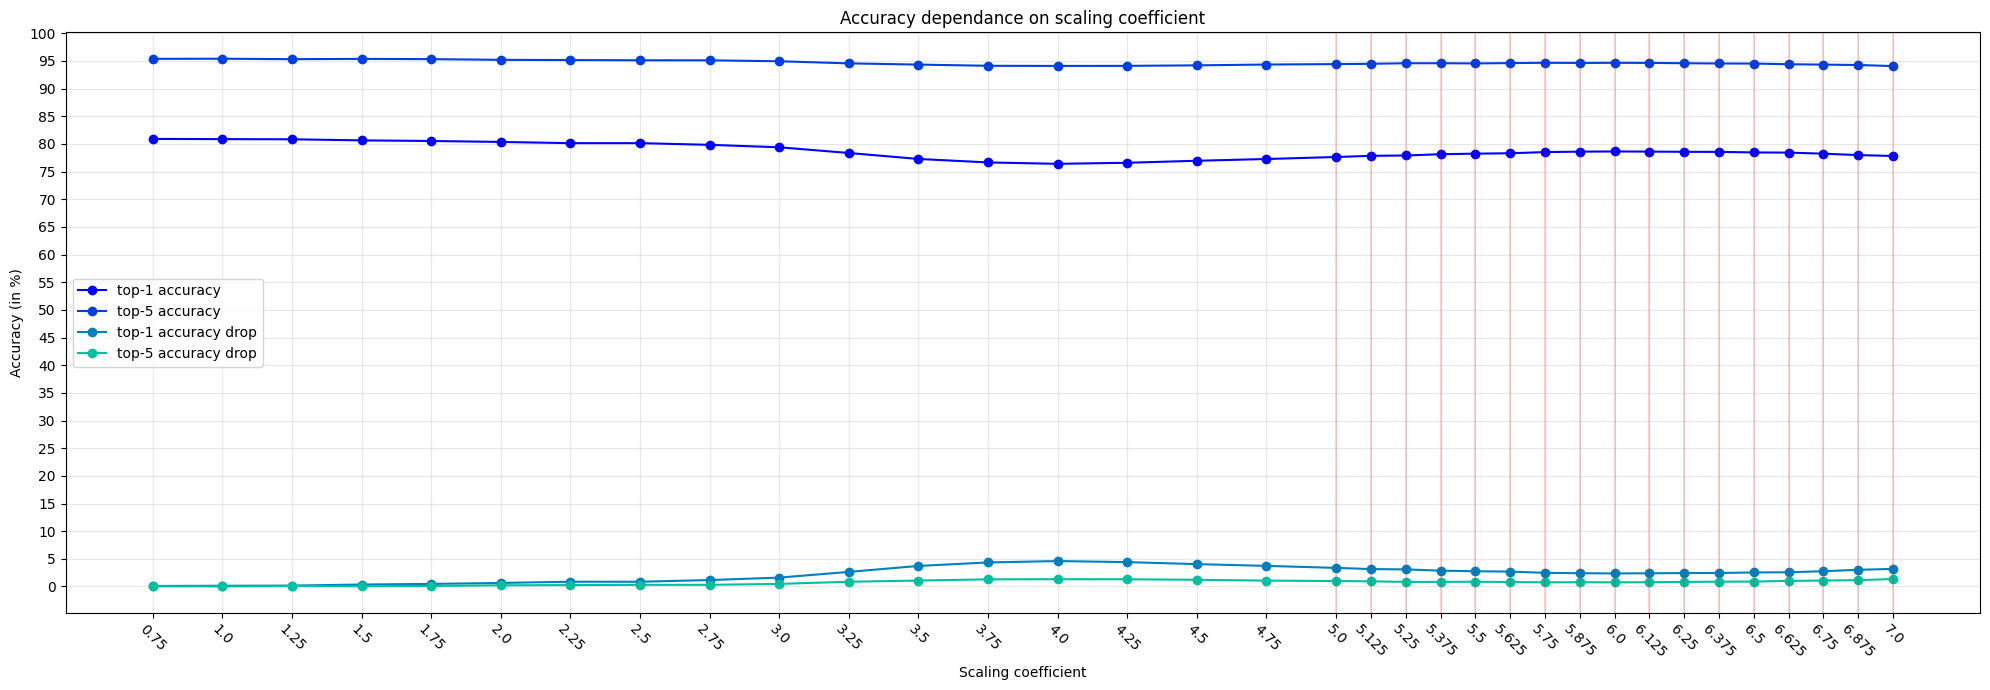

In [ ]:
plot_scale_k_metrics(
    [top1_bins, top5_bins, drops1, drops5],
    ["top-1 accuracy", "top-5 accuracy", "top-1 accuracy drop", "top-5 accuracy drop"],
    drops1_truebin.keys() # type: ignore
)

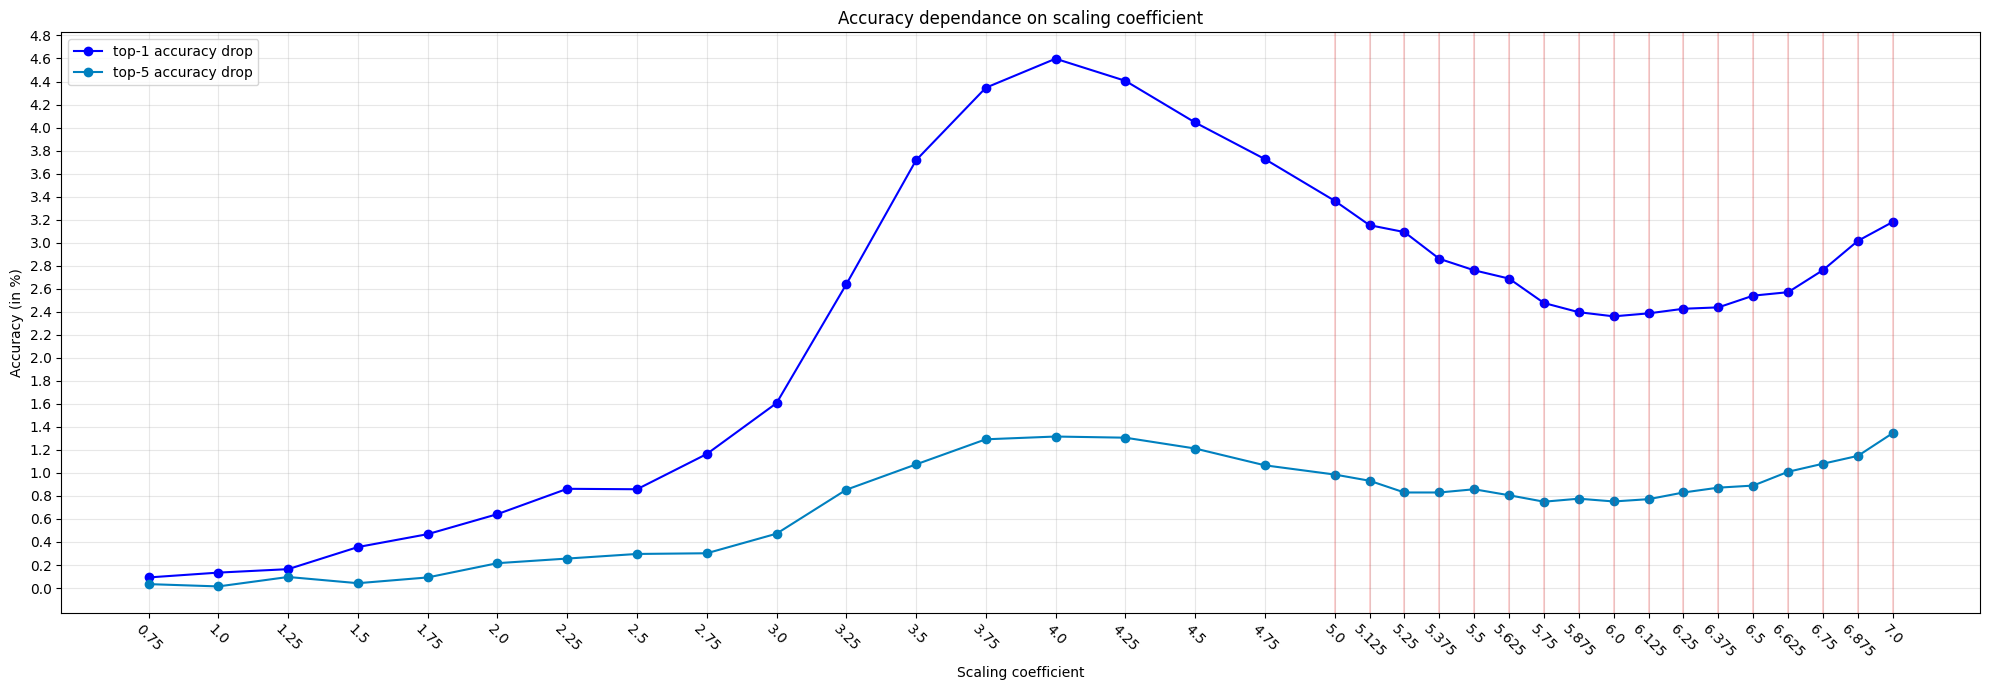

In [68]:
plot_scale_k_metrics(
    [drops1, drops5],
    ["top-1 accuracy drop", "top-5 accuracy drop"],
    drops1_truebin.keys()
)